In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Spotify data
spotify = pd.read_csv('../data/raw/spotify_real/278k_song_labelled.csv')

# Weather data
temperature = pd.read_csv('../data/raw/weather_real/temperature.csv')
humidity = pd.read_csv('../data/raw/weather_real/humidity.csv')
weather_desc = pd.read_csv('../data/raw/weather_real/weather_description.csv')
city_attrs = pd.read_csv('../data/raw/weather_real/city_attributes.csv')

print("Spotify shape:", spotify.shape)
print("Temperature shape:", temperature.shape)
print("Weather description shape:", weather_desc.shape)
print("City attributes shape:", city_attrs.shape)

Spotify shape: (277938, 13)
Temperature shape: (45253, 37)
Weather description shape: (45253, 37)
City attributes shape: (36, 4)


In [5]:
print("=== SPOTIFY ===")
print(spotify.head())
print("\nColumns:", spotify.columns.tolist())

print("\n=== TEMPERATURE ===")
print(temperature.head())

print("\n=== WEATHER DESCRIPTION ===")
print(weather_desc.head())

print("\n=== CITY ATTRIBUTES ===")
print(city_attrs.head())

=== SPOTIFY ===
   Unnamed: 0  duration (ms)  danceability  energy  loudness  speechiness  \
0           0       195000.0         0.611   0.614    -8.815       0.0672   
1           1       194641.0         0.638   0.781    -6.848       0.0285   
2           2       217573.0         0.560   0.810    -8.029       0.0872   
3           3       443478.0         0.525   0.699    -4.571       0.0353   
4           4       225862.0         0.367   0.771    -5.863       0.1060   

   acousticness  instrumentalness  liveness  valence    tempo     spec_rate  \
0        0.0169          0.000794    0.7530    0.520  128.050  3.446154e-07   
1        0.0118          0.009530    0.3490    0.250  122.985  1.464234e-07   
2        0.0071          0.000008    0.2410    0.247  170.044  4.007850e-07   
3        0.0178          0.000088    0.0888    0.199   92.011  7.959809e-08   
4        0.3650          0.000001    0.0965    0.163  115.917  4.693131e-07   

   labels  
0       2  
1       1  
2       1 

In [6]:
print("=== SPOTIFY MOOD LABELS ===")
print(spotify['labels'].value_counts())

print("\n=== SPOTIFY VALENCE STATS ===")
print(spotify['valence'].describe())

print("\n=== WEATHER DESCRIPTION UNIQUE VALUES (Vancouver sample) ===")
print(weather_desc['Vancouver'].value_counts().head(10))

print("\n=== DATE RANGE ===")
print("Weather from:", temperature['datetime'].min())
print("Weather to:", temperature['datetime'].max())

=== SPOTIFY MOOD LABELS ===
labels
1    106429
0     82058
2     47065
3     42386
Name: count, dtype: int64

=== SPOTIFY VALENCE STATS ===
count    277938.000000
mean          0.449602
std           0.267471
min           0.000000
25%           0.220000
50%           0.434000
75%           0.665000
max           1.000000
Name: valence, dtype: float64

=== WEATHER DESCRIPTION UNIQUE VALUES (Vancouver sample) ===
Vancouver
sky is clear                   12805
light rain                      5569
overcast clouds                 4676
broken clouds                   4489
mist                            3588
few clouds                      3068
scattered clouds                2627
light intensity shower rain     1710
moderate rain                   1643
fog                             1543
Name: count, dtype: int64

=== DATE RANGE ===
Weather from: 2012-10-01 12:00:00
Weather to: 2017-11-30 00:00:00


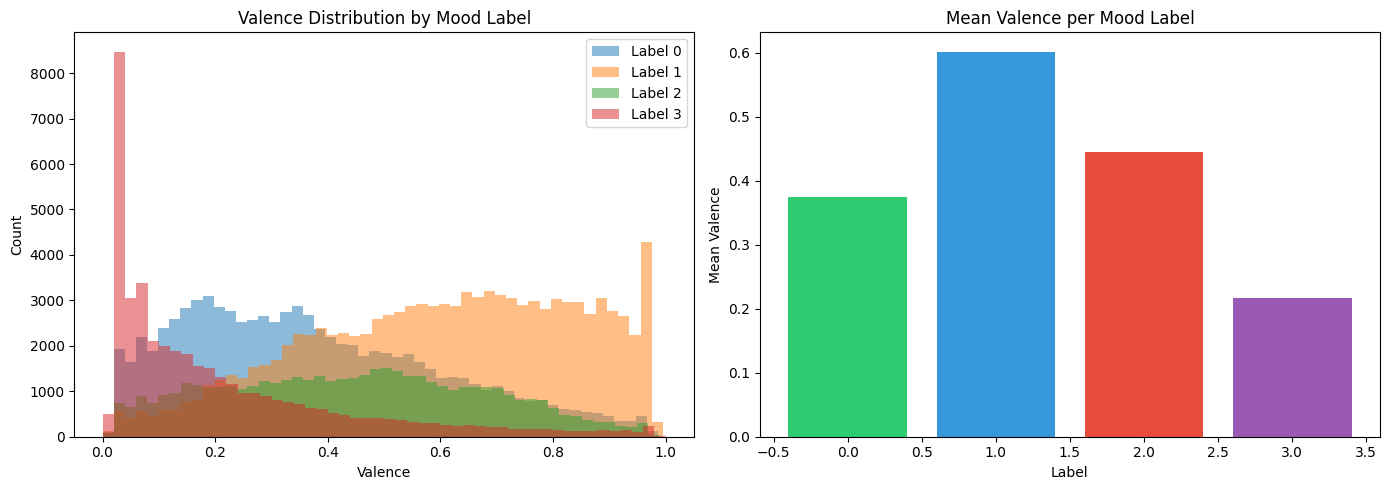

Mean valence per label:
labels
0    0.375
1    0.602
2    0.445
3    0.217
Name: valence, dtype: float64


In [7]:
# Valence distribution by mood label
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: valence distribution by label
for label in sorted(spotify['labels'].unique()):
    subset = spotify[spotify['labels'] == label]['valence']
    axes[0].hist(subset, bins=50, alpha=0.5, label=f'Label {label}')
axes[0].set_title('Valence Distribution by Mood Label')
axes[0].set_xlabel('Valence')
axes[0].set_ylabel('Count')
axes[0].legend()

# Plot 2: mean valence per label
mean_valence = spotify.groupby('labels')['valence'].mean()
axes[1].bar(mean_valence.index, mean_valence.values, color=['#2ecc71','#3498db','#e74c3c','#9b59b6'])
axes[1].set_title('Mean Valence per Mood Label')
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Mean Valence')

plt.tight_layout()
plt.savefig('../results/figures/valence_by_label.png', dpi=150)
plt.show()
print("Mean valence per label:")
print(mean_valence.round(3))